In [1]:
pip install qiskit qiskit-aer matplotlib pylatexenc


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=3bd4077ea905d22076d9b3dbea34994544e99cd71e075271c843ae1d9ff30f92
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# Experiment - 1 : Phase Kickback

Experiment: Phase Kickback


Circuit:
      ┌───┐          ┌───┐┌─┐
q_0: ┤ H ├───────■──┤ H ├┤M├
     ├───┤┌───┐┌─┴─┐├───┤└╥┘
q_1: ┤ X ├┤ H ├┤ X ├┤ H ├─╫─
     └───┘└───┘└───┘└───┘ ║ 
c: 1/═════════════════════╩═
                          0 
Counts: {'1': 1024}


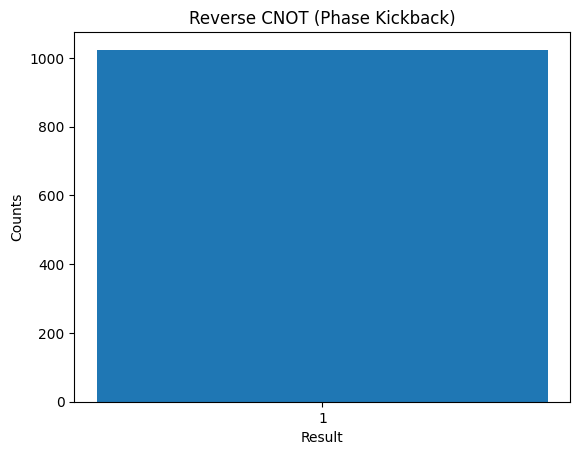


Circuit:
      ┌───┐         
q_0: ┤ H ├─■───────
     ├───┤ │P(π/4) 
q_1: ┤ X ├─■───────
     └───┘         

Statevector:
 Statevector([0.        +0.j , 0.        +0.j , 0.70710678+0.j ,
             0.5       +0.5j],
            dims=(2, 2))

Done.


In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import math



def reverse_cnot():
    qc = QuantumCircuit(2, 1)

    # Prepare |+⟩ and |−⟩
    qc.h(0)
    qc.x(1)
    qc.h(1)

    # CNOT → phase kickback
    qc.cx(0, 1)

    # Interference + measurement
    qc.h(1)
    qc.h(0)
    qc.measure(0, 0)

    print("\nCircuit:\n", qc.draw())

    sim = AerSimulator()
    counts = sim.run(transpile(qc, sim), shots=1024).result().get_counts()

    print("Counts:", counts)

    # Plot
    plt.bar(counts.keys(), counts.values())
    plt.title("Reverse CNOT (Phase Kickback)")
    plt.xlabel("Result")
    plt.ylabel("Counts")
    plt.show()

    return qc, counts



# PART B — T Gate Phase Kickback

def t_kickback():
    qc = QuantumCircuit(2)

    # Prepare |+⟩ and |1⟩
    qc.h(0)
    qc.x(1)

    # Controlled-T (CP π/4)
    qc.cp(math.pi / 4, 0, 1)

    print("\nCircuit:\n", qc.draw())

    sv = Statevector(qc)
    print("\nStatevector:\n", sv)

    return qc



if __name__ == "__main__":
    print("Experiment: Phase Kickback\n")

    reverse_cnot()
    t_kickback()

    print("\nDone.")

# Experiment 2 : Deutsch Algorithm


Oracle: constant_0
     ┌───┐     ┌─────────────┐┌───┐┌─┐
q_0: ┤ H ├─────┤0            ├┤ H ├┤M├
     ├───┤┌───┐│  circuit-52 │└───┘└╥┘
q_1: ┤ X ├┤ H ├┤1            ├──────╫─
     └───┘└───┘└─────────────┘      ║ 
c: 1/═══════════════════════════════╩═
                                    0 
Counts: {'0': 1024}
Result: CONSTANT


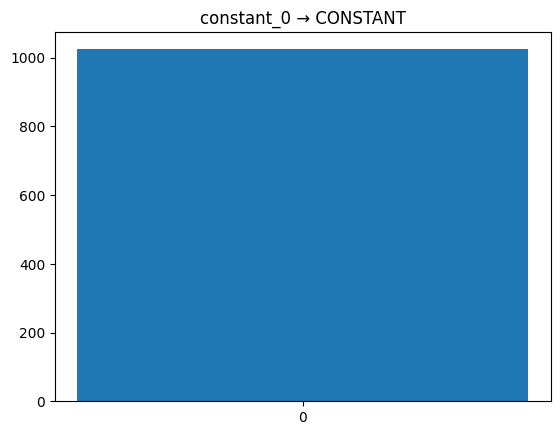


Oracle: constant_1
     ┌───┐     ┌─────────────┐┌───┐┌─┐
q_0: ┤ H ├─────┤0            ├┤ H ├┤M├
     ├───┤┌───┐│  circuit-57 │└───┘└╥┘
q_1: ┤ X ├┤ H ├┤1            ├──────╫─
     └───┘└───┘└─────────────┘      ║ 
c: 1/═══════════════════════════════╩═
                                    0 
Counts: {'0': 1024}
Result: CONSTANT


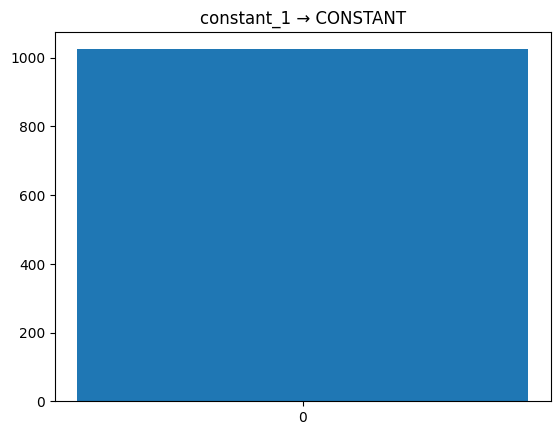


Oracle: identity
     ┌───┐     ┌─────────────┐┌───┐┌─┐
q_0: ┤ H ├─────┤0            ├┤ H ├┤M├
     ├───┤┌───┐│  circuit-62 │└───┘└╥┘
q_1: ┤ X ├┤ H ├┤1            ├──────╫─
     └───┘└───┘└─────────────┘      ║ 
c: 1/═══════════════════════════════╩═
                                    0 
Counts: {'1': 1024}
Result: BALANCED


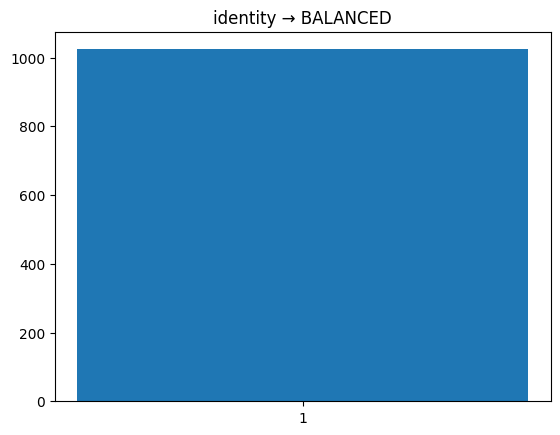


Oracle: negation
     ┌───┐     ┌─────────────┐┌───┐┌─┐
q_0: ┤ H ├─────┤0            ├┤ H ├┤M├
     ├───┤┌───┐│  circuit-67 │└───┘└╥┘
q_1: ┤ X ├┤ H ├┤1            ├──────╫─
     └───┘└───┘└─────────────┘      ║ 
c: 1/═══════════════════════════════╩═
                                    0 
Counts: {'1': 1024}
Result: BALANCED


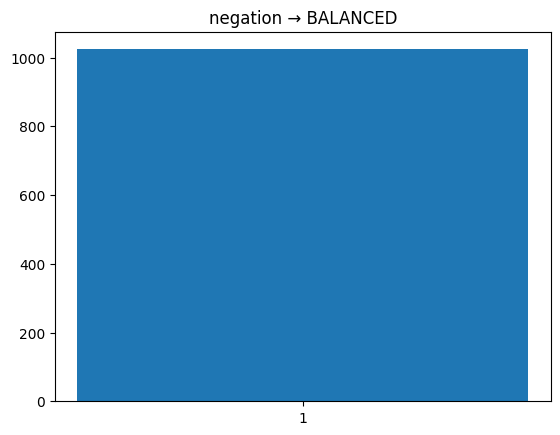

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import math


def build_oracle(kind):
    qc = QuantumCircuit(2)

    if kind == "constant_1":
        qc.x(1)
    elif kind == "identity":
        qc.cx(0, 1)
    elif kind == "negation":
        qc.cx(0, 1)
        qc.x(1)

    return qc



def deutsch(kind):
    qc = QuantumCircuit(2, 1)

    qc.x(1)        # |1⟩
    qc.h([0, 1])   # create |+⟩|−⟩

    qc.append(build_oracle(kind), [0, 1])

    qc.h(0)
    qc.measure(0, 0)

    sim = AerSimulator()
    counts = sim.run(transpile(qc, sim), shots=1024).result().get_counts()

    result = "CONSTANT" if list(counts.keys())[0] == "0" else "BALANCED"

    return qc, counts, result


def run():
    oracles = ["constant_0", "constant_1", "identity", "negation"]

    for o in oracles:
        qc, counts, res = deutsch(o)

        print(f"\nOracle: {o}")
        print(qc.draw())
        print("Counts:", counts)
        print("Result:", res)

        plt.bar(counts.keys(), counts.values())
        plt.title(f"{o} → {res}")
        plt.show()


if __name__ == "__main__":
    run()

# Experiment 3 : Deutsch-Jozsa Algorithm


n=2, oracle=constant_0
     ┌───┐     ┌─────────────┐┌───┐┌─┐   
q_0: ┤ H ├─────┤0            ├┤ H ├┤M├───
     ├───┤     │             │├───┤└╥┘┌─┐
q_1: ┤ H ├─────┤1 circuit-72 ├┤ H ├─╫─┤M├
     ├───┤┌───┐│             │└───┘ ║ └╥┘
q_2: ┤ X ├┤ H ├┤2            ├──────╫──╫─
     └───┘└───┘└─────────────┘      ║  ║ 
c: 2/═══════════════════════════════╩══╩═
                                    0  1 
Counts: {'00': 1024}
Result: CONSTANT


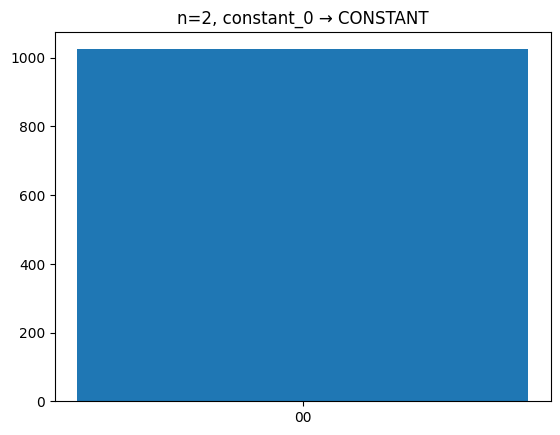


n=2, oracle=balanced
     ┌───┐     ┌─────────────┐┌───┐┌─┐   
q_0: ┤ H ├─────┤0            ├┤ H ├┤M├───
     ├───┤     │             │├───┤└╥┘┌─┐
q_1: ┤ H ├─────┤1 circuit-77 ├┤ H ├─╫─┤M├
     ├───┤┌───┐│             │└───┘ ║ └╥┘
q_2: ┤ X ├┤ H ├┤2            ├──────╫──╫─
     └───┘└───┘└─────────────┘      ║  ║ 
c: 2/═══════════════════════════════╩══╩═
                                    0  1 
Counts: {'11': 1024}
Result: BALANCED


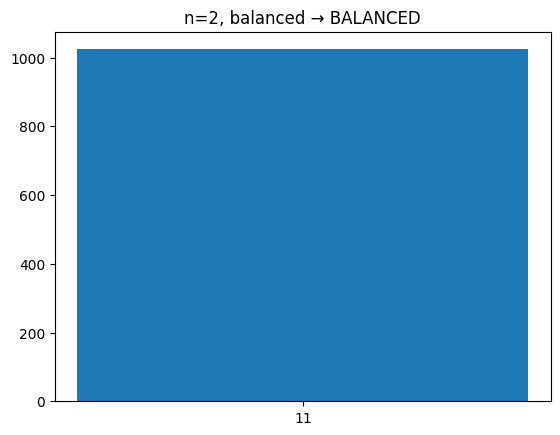


n=3, oracle=balanced
     ┌───┐     ┌─────────────┐┌───┐┌─┐      
q_0: ┤ H ├─────┤0            ├┤ H ├┤M├──────
     ├───┤     │             │├───┤└╥┘┌─┐   
q_1: ┤ H ├─────┤1            ├┤ H ├─╫─┤M├───
     ├───┤     │  circuit-82 │├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─────┤2            ├┤ H ├─╫──╫─┤M├
     ├───┤┌───┐│             │└───┘ ║  ║ └╥┘
q_3: ┤ X ├┤ H ├┤3            ├──────╫──╫──╫─
     └───┘└───┘└─────────────┘      ║  ║  ║ 
c: 3/═══════════════════════════════╩══╩══╩═
                                    0  1  2 
Counts: {'111': 1024}
Result: BALANCED


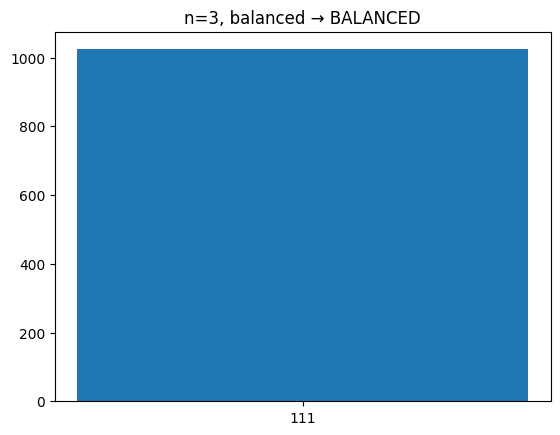

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt



def build_oracle(n, kind):
    qc = QuantumCircuit(n + 1)

    if kind == "constant_1":
        qc.x(n)
    elif kind == "balanced":
        for i in range(n):
            qc.cx(i, n)

    return qc


# DEUTSCH–JOZSA
def deutsch_jozsa(n, kind):
    qc = QuantumCircuit(n + 1, n)

    qc.x(n)                     # ancilla = |1⟩
    qc.h(range(n + 1))          # superposition

    qc.append(build_oracle(n, kind), range(n + 1))

    qc.h(range(n))              # interference
    qc.measure(range(n), range(n))

    sim = AerSimulator()
    counts = sim.run(transpile(qc, sim), shots=1024).result().get_counts()

    result = "CONSTANT" if "0" * n in counts else "BALANCED"

    return qc, counts, result


# RUN TESTS
def run():
    tests = [(2, "constant_0"), (2, "balanced"), (3, "balanced")]

    for n, kind in tests:
        qc, counts, res = deutsch_jozsa(n, kind)

        print(f"\nn={n}, oracle={kind}")
        print(qc.draw())
        print("Counts:", counts)
        print("Result:", res)

        plt.bar(counts.keys(), counts.values())
        plt.title(f"n={n}, {kind} → {res}")
        plt.show()


if __name__ == "__main__":
    run()